<a href="https://colab.research.google.com/github/Dhlih/Submission-Dicoding-Analisis-Sentimen/blob/main/Pelatihan_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Import Library

In [331]:
import pandas as pd  # Pandas untuk manipulasi dan analisis data
pd.options.mode.chained_assignment = None  # Menonaktifkan peringatan chaining

import numpy as np  # NumPy untuk komputasi numerik
import matplotlib.pyplot as plt  # Matplotlib untuk visualisasi data
import seaborn as sns  # Seaborn untuk visualisasi data statistik, mengatur gaya visualisasi
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix  # Evaluasi model klasifikasi

import re  # Modul untuk bekerja dengan ekspresi reguler
import string  # Berisi konstanta string, seperti tanda baca

from nltk.tokenize import word_tokenize  # Tokenisasi teks
from nltk.corpus import stopwords  # Daftar kata-kata berhenti dalam teks

from wordcloud import WordCloud  # Membuat visualisasi berbentuk awan kata (word cloud) dari teks

!pip install emoji

import nltk  # Import pustaka NLTK (Natural Language Toolkit).
nltk.download('punkt_tab')  # Mengunduh dataset yang diperlukan untuk tokenisasi teks.

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

## Loading Dataset

In [332]:
df = pd.read_csv("ulasan_ipusnas.csv")
df.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,82e83362-0763-4eab-9e3d-fc11930634a8,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"gabisa minjem, kesalahan pengiriman data mulu,...",1,124,2.1.0,2026-02-25 12:21:00,NaN,NaN,2.1.0
1,eb1e116f-41d2-4699-bee6-a86918bbd023,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"kadang bisa minjem buku kadang engga, awalnya ...",2,234,2.1.0,2026-02-01 08:49:07,NaN,NaN,2.1.0
2,c28895ee-210a-4be9-81a3-7ad9c1a8b191,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Ini kenapa setelah update data peminjaman, ant...",2,369,2.0.6,2026-01-26 15:43:13,NaN,NaN,2.0.6
3,d6273ac9-49fc-4d54-a80f-d01210795215,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Halo ipusnas! Kenapa dari bulan Januari sampai...,3,31,2.1.0,2026-02-23 06:17:42,NaN,NaN,2.1.0
4,682da2e3-3176-4589-87bb-956495cf64a7,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Aplikasi ini tujuannya memudahkan akses baca s...,1,185,2.1.0,2026-02-22 07:15:35,NaN,NaN,2.1.0


In [333]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19959 entries, 0 to 19958
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   reviewId              19959 non-null  object
 1   userName              19959 non-null  object
 2   userImage             19959 non-null  object
 3   content               19959 non-null  object
 4   score                 19959 non-null  int64 
 5   thumbsUpCount         19959 non-null  int64 
 6   reviewCreatedVersion  14981 non-null  object
 7   at                    19959 non-null  object
 8   replyContent          13130 non-null  object
 9   repliedAt             13130 non-null  object
 10  appVersion            14981 non-null  object
dtypes: int64(2), object(9)
memory usage: 1.7+ MB


In [334]:
df.isnull().sum()

,0
reviewId,0
userName,0
userImage,0
content,0
score,0
thumbsUpCount,0
reviewCreatedVersion,4978
at,0
replyContent,6829
repliedAt,6829


In [335]:
clean_df = df.dropna()
clean_df.isnull().sum()

,0
reviewId,0
userName,0
userImage,0
content,0
score,0
thumbsUpCount,0
reviewCreatedVersion,0
at,0
replyContent,0
repliedAt,0


In [336]:
clean_df.duplicated().sum()

np.int64(0)

## Preprocess Text

In [363]:
import emoji

def cleaningText(text):
    # 1. Ubah emoji menjadi teks (Misal: 😂 menjadi :face_with_tears_of_joy:)
    text = emoji.demojize(text, delimiters=(" ", " "))

    # 2. Pembersihan standar
    text = re.sub(r'@[A-Za-z0-9]+', '', text) # menghapus mention
    text = re.sub(r'#[A-Za-z0-9]+', '', text) # menghapus hashtag
    text = re.sub(r'RT[\s]', '', text)         # menghapus RT
    text = re.sub(r"http\S+", '', text)       # menghapus link
    text = re.sub(r'[0-9]+', '', text)         # menghapus angka

    # 3. Menghapus karakter selain huruf, angka, spasi, dan UNDERSCORE
    text = re.sub(r'[^\w\s]', '', text)

    text = text.replace('\n', ' ') # mengganti baris baru dengan spasi

    # 4. Menghapus tanda baca (kecuali underscore agar label emoji tetap utuh)
    punc_clean = string.punctuation.replace('_', '')
    text = text.translate(str.maketrans('', '', punc_clean))

    # 5. Merapikan spasi berlebih
    text = re.sub(r'\s+', ' ', text)
    text = text.strip()

    return text

def casefoldingText(text): # Mengubah semua karakter dalam teks menjadi huruf kecil
    text = text.lower()
    return text

def tokenizingText(text): # Memecah atau membagi string, teks menjadi daftar token
    text = word_tokenize(text)
    return text

def toSentence(list_words): # Mengubah daftar kata menjadi kalimat
    sentence = ' '.join(word for word in list_words)
    return sentence

In [338]:
import json

with open('slang_words.json', 'r') as f:
    slang_words = json.load(f)

def fix_slangwords(text):
    words = text.split()
    fixed_words = []

    for word in words:
        if word.lower() in slang_words:
            fixed_words.append(slang_words[word.lower()])
        else:
            fixed_words.append(word)

    fixed_text = ' '.join(fixed_words)
    return fixed_text

with open('stop_words.txt', 'r') as f:
    stop_words = set(f.read().splitlines())

def filteringText(text): # Menghapus stopwords dalam teks
    filtered = []
    for txt in text:
        if txt not in stop_words:
            filtered.append(txt)
    text = filtered
    return text

In [339]:
# Membersihkan teks dan menyimpannya di kolom 'text_clean'
clean_df['text_clean'] = clean_df['content'].apply(cleaningText)

# Mengubah huruf dalam teks menjadi huruf kecil dan menyimpannya di 'text_casefoldingText'
clean_df['text_casefoldingText'] = clean_df['text_clean'].apply(casefoldingText)

# Mengganti kata-kata slang dengan kata-kata standar dan menyimpannya di 'text_slangwords'
clean_df['text_slangwords'] = clean_df['text_casefoldingText'].apply(fix_slangwords)

# Memecah teks menjadi token (kata-kata) dan menyimpannya di 'text_tokenizingText'
clean_df['text_tokenizingText'] = clean_df['text_slangwords'].apply(tokenizingText)

# Menghapus kata-kata stop (kata-kata umum) dan menyimpannya di 'text_stopword'
clean_df['text_stopword'] = clean_df['text_tokenizingText'].apply(filteringText)

# Menggabungkan token-token menjadi kalimat dan menyimpannya di 'text_akhir'
clean_df['text_akhir'] = clean_df['text_stopword'].apply(toSentence)

In [340]:
clean_df.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,text_clean,text_casefoldingText,text_slangwords,text_tokenizingText,text_stopword,text_akhir
23,d5f0a704-9260-47f4-960d-153ab64d6cf4,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Setelah diupdate krn keperluan tugas, rupanya ...",1,46,2.0.6,2026-01-29 01:38:27,Hallo Liliy! Terima kasih sudah memberikan ula...,2022-03-27 08:52:58,2.0.6,Setelah diupdate krn keperluan tugas rupanya g...,setelah diupdate krn keperluan tugas rupanya g...,setelah diupdate karena keperluan tugas rupany...,"[setelah, diupdate, karena, keperluan, tugas, ...","[diupdate, keperluan, tugas, rupanya, gak, bis...",diupdate keperluan tugas rupanya gak bisa logi...
28,27609d0c-739b-4a34-847b-ff4a6a8c3fdc,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Saya Download Aplikasi Ipusnas Langsung di Pla...,1,12,2.0.6,2026-01-25 02:42:18,Hallo Usman! Kami mohon maaf atas kendala dan ...,2023-04-01 11:01:42,2.0.6,Saya Download Aplikasi Ipusnas Langsung di Pla...,saya download aplikasi ipusnas langsung di pla...,saya download aplikasi ipusnas langsung di pla...,"[saya, download, aplikasi, ipusnas, langsung, ...","[download, langsung, playstorre, tapi, log, in...",download langsung playstorre tapi log in muncu...
33,96709d16-28e3-4dc9-aef2-7562a85b129e,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Terima kasih sudah memberi kesempatan untuk ya...,2,3,2.0.6,2026-01-24 23:28:33,Hallo Puristi! Kami mohon maaf atas ketidaknya...,2024-09-09 01:34:17,2.0.6,Terima kasih sudah memberi kesempatan untuk ya...,terima kasih sudah memberi kesempatan untuk ya...,terima kasih sudah memberi kesempatan untuk ya...,"[terima, kasih, sudah, memberi, kesempatan, un...","[terima, kasih, sudah, kesempatan, ingin, memb...",terima kasih sudah kesempatan ingin membaca be...
41,03dc5e28-0e6f-403a-87f1-694e00c29b5d,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,astaga ipusnas... kenapa makin jelek aja sih.....,1,15,2.0.6,2026-01-29 23:28:07,Hallo Pujiana! Kami mohon maaf atas ketidaknya...,2023-10-01 07:16:16,2.0.6,astaga ipusnas kenapa makin jelek aja sih sebe...,astaga ipusnas kenapa makin jelek aja sih sebe...,astaga ipusnas kenapa makin jelek saja sih seb...,"[astaga, ipusnas, kenapa, makin, jelek, saja, ...","[astaga, kenapa, makin, jelek, update, tidak, ...",astaga kenapa makin jelek update tidak bisa pi...
54,b74d631a-0828-44db-bea5-8d459c8ca039,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Koleksi bukunya banyak banget! Meski harus nga...,5,2,2.1.0,2026-02-13 03:10:28,Hallo Pine! Kami mohon maaf atas kendala dan k...,2024-05-20 22:44:26,2.1.0,Koleksi bukunya banyak banget Meski harus ngan...,koleksi bukunya banyak banget meski harus ngan...,koleksi bukunya banyak banget meski harus meng...,"[koleksi, bukunya, banyak, banget, meski, haru...","[koleksi, banyak, banget, meski, harus, mengan...",koleksi banyak banget meski harus mengantri ba...


## Pelabelan

In [341]:
import csv
import requests
from io import StringIO

# Membaca data kamus kata-kata positif dari GitHub
lexicon_positive = dict()

response = requests.get('https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_positive.csv')
# Mengirim permintaan HTTP untuk mendapatkan file CSV dari GitHub

if response.status_code == 200:
    # Jika permintaan berhasil
    reader = csv.reader(StringIO(response.text), delimiter=',')
    # Membaca teks respons sebagai file CSV menggunakan pembaca CSV dengan pemisah koma
    for row in reader:
      # Mengulangi setiap baris dalam file CSV
      lexicon_positive[row[0]] = int(row[1])
      # Menambahkan kata-kata positif dan skornya ke dalam kamus lexicon_positive
else:
    print("Failed to fetch positive lexicon data")

# Membaca data kamus kata-kata negatif dari GitHub
lexicon_negative = dict()

response = requests.get('https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_negative.csv')
# Mengirim permintaan HTTP untuk mendapatkan file CSV dari GitHub

if response.status_code == 200:
    # Jika permintaan berhasil
    reader = csv.reader(StringIO(response.text), delimiter=',')
    # Membaca teks respons sebagai file CSV menggunakan pembaca CSV dengan pemisah koma

    for row in reader:
      # Mengulangi setiap baris dalam file CSV
      lexicon_negative[row[0]] = int(row[1])
      # Menambahkan kata-kata negatif dan skornya dalam kamus lexicon_negative
else:
    print("Failed to fetch negative lexicon data")

In [342]:
# Fungsi untuk menentukan polaritas sentimen dari tweet

def sentiment_analysis_lexicon_indonesia(text):
    #for word in text:
    score = 0
    # Inisialisasi skor sentimen ke 0
    # tidak perlu split karena text stopword berupa list
    for word in text:
        # Mengulangi setiap kata dalam teks

        if (word in lexicon_positive):
            score = score + lexicon_positive[word]
            # Jika kata ada dalam kamus positif, tambahkan skornya ke skor sentimen

    for word in text:
        # Mengulangi setiap kata dalam teks (sekali lagi)

        if (word in lexicon_negative):
            score = score + lexicon_negative[word]
            # Jika kata ada dalam kamus negatif, kurangkan skornya dari skor sentimen

    polarity=''
    # Inisialisasi variabel polaritas

    if (score >= 0):
        polarity = 'positive'
        # Jika skor sentimen lebih besar atau sama dengan 0, maka polaritas adalah positif
    elif (score < 0):
        polarity = 'negative'
        # Jika skor sentimen kurang dari 0, maka polaritas adalah negatif
    else:
        polarity = 'neutral'
    # Ini adalah bagian yang bisa digunakan untuk menentukan polaritas netral jika diperlukan

    return score, polarity
    # Mengembalikan skor sentimen dan polaritas teks

In [343]:
results = clean_df['text_stopword'].apply(sentiment_analysis_lexicon_indonesia)
results = list(zip(*results))

clean_df['polarity_score'] = results[0]
clean_df['polarity'] = results[1]

In [344]:
# Mengubah label kategorikal menjadi numerik
label_mapping = {
    'negative': 0,
    'positive': 1,
}
clean_df["polarity_encoded"] = clean_df["polarity"].map(label_mapping)

In [345]:
clean_df["polarity"].value_counts()

,count
polarity,
negative,5220
positive,4845


([<matplotlib.patches.Wedge at 0x7b148db8d040>,
 [Text(-0.0643401119852141, 1.0981167287632632, 'negative'),
  Text(0.0643398152684837, -1.0981167461482488, 'positive')],
 [Text(-0.0350946065373895, 0.5989727611435981, '51.9%'),
  Text(0.0350944446919002, -0.5989727706263175, '48.1%')])

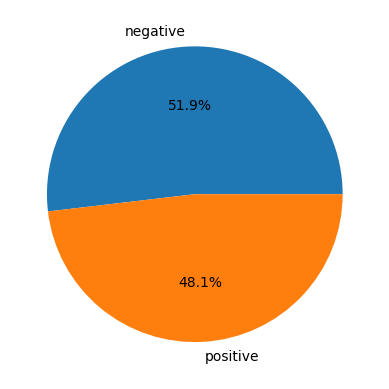

In [346]:
plt.pie(clean_df["polarity_encoded"].value_counts(), labels=clean_df["polarity"].value_counts().index, autopct='%1.1f%%')

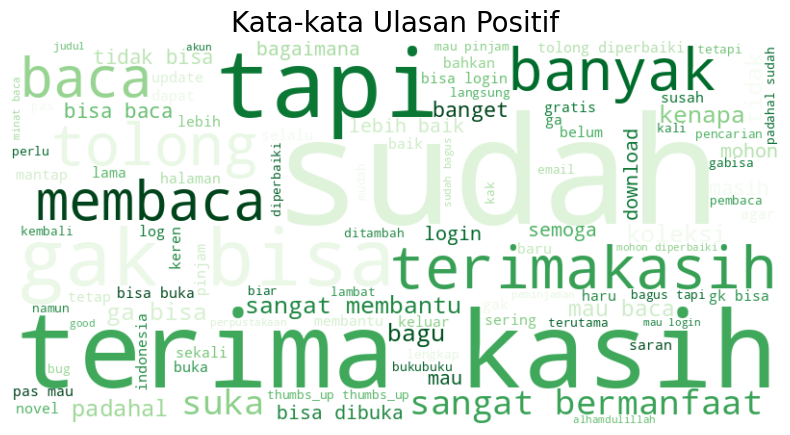

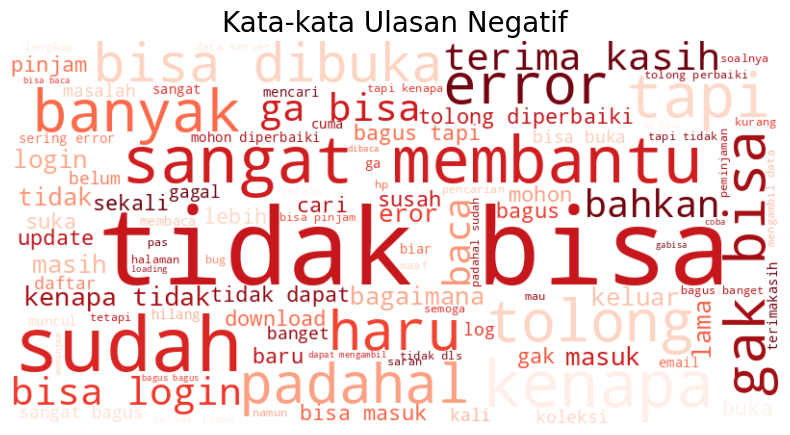

In [370]:
# 1. Pisahkan data berdasarkan polaritas
data_negatif = clean_df[clean_df['polarity_encoded'] == 0]['text_akhir']
data_positif = clean_df[clean_df['polarity_encoded'] == 1]['text_akhir']

# 2. Gabungkan semua baris teks menjadi satu string panjang
teks_negatif = " ".join(review for review in data_negatif)
teks_positif = " ".join(review for review in data_positif)

# 3. Fungsi untuk membuat Word Cloud
def buat_wordcloud(teks, judul, warna_peta):
    wc = WordCloud(
        width=800,
        height=400,
        background_color='white',
        colormap=warna_peta, # 'Greens' untuk positif, 'Reds' untuk negatif
        max_words=100
    ).generate(teks)

    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.title(judul, fontsize=20)
    plt.axis('off')

    plt.show()

# 4. Tampilkan Word Cloud Positif
buat_wordcloud(teks_positif, "Kata-kata Ulasan Positif", "Greens")

# 5. Tampilkan Word Cloud Negatif
buat_wordcloud(teks_negatif, "Kata-kata Ulasan Negatif", "Reds")

## Ekstraksi Fitur

In [348]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

In [377]:
# Pisahkan data menjadi fitur (tweet) dan label (sentimen)
X = clean_df['text_akhir']
y = clean_df['polarity_encoded']

# Ekstraksi fitur dengan TF-IDF
# max_df = abaikan kata yang muncul lebih dari 80% total ulasan, min_df =  abaikan kata yang muncul kurang dari 17x
tfidf = TfidfVectorizer(max_features=1000, min_df=17, max_df=0.8, ngram_range=(1,2))
X_tfidf = tfidf.fit_transform(X)

## Data Splitting dan Pelatihan Model

In [378]:
# Konversi hasil ekstraksi fitur menjadi dataframe
features_df = pd.DataFrame(X_tfidf.toarray(), columns=tfidf.get_feature_names_out())
features_df

,agak,agar,agar bisa,agar lebih,agar tidak,akhirakhir,akhirnya,akses,akun,alangkah,...,valid,verifikasi,verifikasi email,versi,via,walau,walaupun,wawasan,wifi,wishlist
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.227353,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10060,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10061,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10062,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10063,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [379]:
# # Splitting data (80 / 20)
X_train_80, X_test_20, y_train_80, y_test_20 = train_test_split(X_tfidf, y, test_size=0.2, random_state=42, stratify=y)

# Splitting data (70 / 30)
X_train_70, X_test_30, y_train_70, y_test_30 = train_test_split(X_tfidf, y, test_size=0.3, random_state=42, stratify=y)

### Logistic Regression (80 / 20)



In [380]:
from sklearn.linear_model import LogisticRegression

# Membuat objek model Logistic Regression
logistic_regression_1 = LogisticRegression()

# Melatih model Logistic Regression pada data pelatihan
logistic_regression_1.fit(X_train_80.toarray(), y_train_80)

# Prediksi sentimen pada data pelatihan dan data uji
y_pred_train_lr_1 = logistic_regression_1.predict(X_train_80.toarray())
y_pred_test_lr_1 = logistic_regression_1.predict(X_test_20.toarray())

# Evaluasi akurasi model Random Forest
accuracy_train_lr_1 = accuracy_score(y_pred_train_lr_1, y_train_80)
accuracy_test_lr_1 = accuracy_score(y_pred_test_lr_1, y_test_20)

# Menampilkan akurasi
print('Linear Regression - accuracy_train:', accuracy_train_lr_1)
print('Linear Regression - accuracy_test:', accuracy_test_lr_1)

Linear Regression - accuracy_train: 0.9225037257824144
Linear Regression - accuracy_test: 0.8976651763537009


### Logistic Regression (70 / 30)

In [381]:
from sklearn.linear_model import LogisticRegression

# Membuat objek model Logistic Regression
logistic_regression_2  = LogisticRegression()

# Melatih model Logistic Regression pada data pelatihan
logistic_regression_2.fit(X_train_70.toarray(), y_train_70)

# Prediksi sentimen pada data pelatihan dan data uji
y_pred_train_lr_2 = logistic_regression_2.predict(X_train_70.toarray())
y_pred_test_lr_2  = logistic_regression_2.predict(X_test_30.toarray())

# Evaluasi akurasi model Random Forest
accuracy_train_lr_2  = accuracy_score(y_pred_train_lr_2, y_train_70)
accuracy_test_lr_2  = accuracy_score(y_pred_test_lr_2, y_test_30)

# Menampilkan akurasi
print('Linear Regression - accuracy_train:', accuracy_train_lr_2 )
print('Linear Regression - accuracy_test:', accuracy_test_lr_2 )

Linear Regression - accuracy_train: 0.9212207239176721
Linear Regression - accuracy_test: 0.890728476821192


### Linear SVC (80/20)

In [382]:
from sklearn.svm import LinearSVC

# LinearSVC cenderung lebih kuat untuk fitur TF-IDF yang banyak
model_svc = LinearSVC(random_state=42)
model_svc.fit(X_train_80, y_train_80) # Tidak perlu .toarray(), SVC mendukung sparse matrix

# Prediksi sentimen pada data pelatihan dan data uji
y_pred_train_svc = model_svc.predict(X_train_80.toarray())
y_pred_test_svc = model_svc.predict(X_test_20.toarray())

# Evaluasi akurasi model Random Forest
accuracy_train_svc = accuracy_score(y_pred_train_svc, y_train_80)
accuracy_test_svc = accuracy_score(y_pred_test_svc, y_test_20)

# Menampilkan akurasi
print('Linear SVC - accuracy_train:', accuracy_train_svc)
print('Linear SVC - accuracy_test:', accuracy_test_svc)

Linear SVC - accuracy_train: 0.9530551415797317
Linear SVC - accuracy_test: 0.9016393442622951


## Evaluasi Model

In [355]:
labels = ['negatif', 'positif']

### Logistic Regression (80 / 20)



In [356]:
print("Classification Report:")
print(classification_report(y_test_20, y_pred_test_lr_1, target_names=labels))

Classification Report:
              precision    recall  f1-score   support

     negatif       0.91      0.89      0.90      1044
     positif       0.88      0.91      0.90       969

    accuracy                           0.90      2013
   macro avg       0.90      0.90      0.90      2013
weighted avg       0.90      0.90      0.90      2013



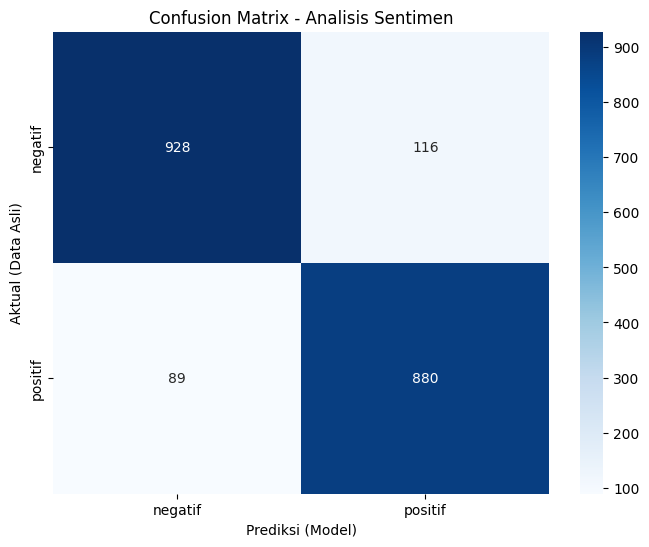

In [357]:
# 1. Hitung Confusion Matrix
cm = confusion_matrix(y_test_20, y_pred_test_lr_1)

# 2. Visualisasi menggunakan Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels,
            yticklabels=labels)

plt.title('Confusion Matrix - Analisis Sentimen')
plt.xlabel('Prediksi (Model)')
plt.ylabel('Aktual (Data Asli)')
plt.show()

### Logistic Regression (70 / 30)



In [358]:
print("Classification Report:")
print(classification_report(y_test_30, y_pred_test_lr_2, target_names=labels))

Classification Report:
              precision    recall  f1-score   support

     negatif       0.90      0.88      0.89      1566
     positif       0.87      0.90      0.89      1454

    accuracy                           0.89      3020
   macro avg       0.89      0.89      0.89      3020
weighted avg       0.89      0.89      0.89      3020



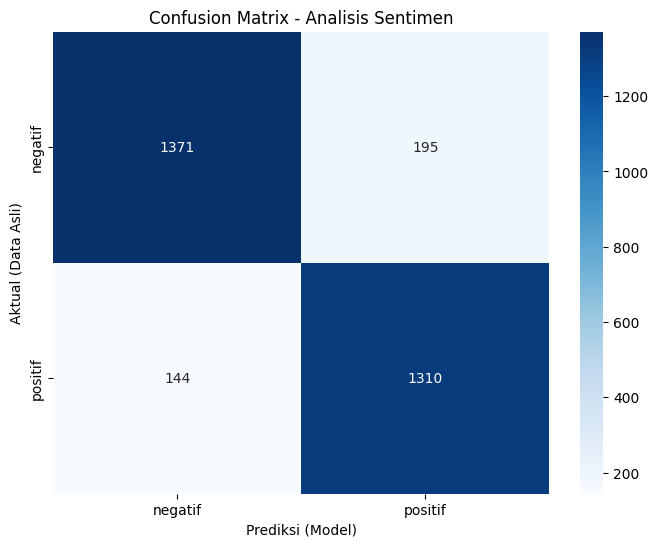

In [359]:
# 1. Hitung Confusion Matrix
cm = confusion_matrix(y_test_30, y_pred_test_lr_2)

# 2. Visualisasi menggunakan Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels,
            yticklabels=labels)

plt.title('Confusion Matrix - Analisis Sentimen')
plt.xlabel('Prediksi (Model)')
plt.ylabel('Aktual (Data Asli)')
plt.show()

### Linear SVC (80 / 20)



In [360]:
print("Classification Report:")
print(classification_report(y_test_20, y_pred_test_svc, target_names=labels))

Classification Report:
              precision    recall  f1-score   support

     negatif       0.92      0.90      0.91      1044
     positif       0.90      0.92      0.91       969

    accuracy                           0.91      2013
   macro avg       0.91      0.91      0.91      2013
weighted avg       0.91      0.91      0.91      2013



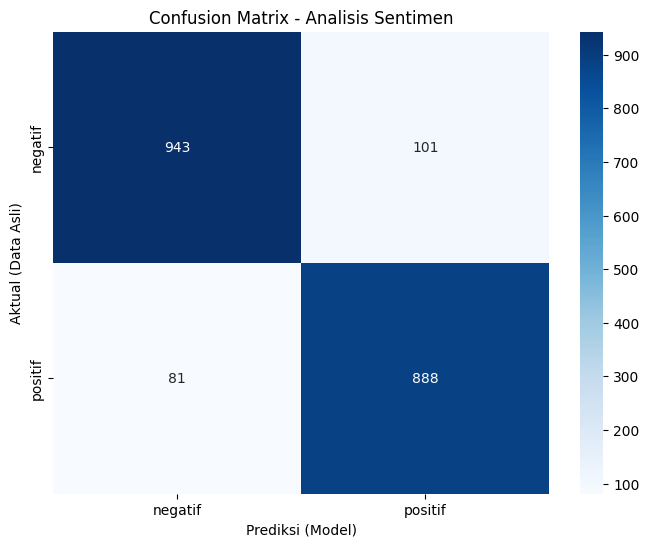

In [369]:
# 1. Hitung Confusion Matrix
cm = confusion_matrix(y_test_20, y_pred_test_svc)

# 2. Visualisasi menggunakan Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels,
            yticklabels=labels)

plt.title('Confusion Matrix - Analisis Sentimen')
plt.xlabel('Prediksi (Model)')
plt.ylabel('Aktual (Data Asli)')
plt.show()

In [368]:
clean_df[clean_df["polarity"] == "negative"]["text_akhir"].head()

,text_akhir
23,diupdate keperluan tugas rupanya gak bisa logi...
28,download langsung playstorre tapi log in muncu...
33,terima kasih sudah kesempatan ingin membaca be...
41,astaga kenapa makin jelek update tidak bisa pi...
54,koleksi banyak banget meski harus mengantri ba...


## Menyimpan Model

In [362]:
import joblib

# Simpan model terbaik dari hasil RandomizedSearch tadi
joblib.dump(model_svc, 'model_sentimen_ipusnas.pkl')

# Simpan juga vectorizer TF-IDF Anda (PENTING!)
# Tanpa ini, Anda tidak bisa memproses teks baru nantinya
joblib.dump(tfidf, 'tfidf_vectorizer.pkl')

print("Model dan Vectorizer berhasil disimpan!")

Model dan Vectorizer berhasil disimpan!
